# Model Analysis

This notebook includes analyses of trained RNN and SINDy models for the constant (simple DDM), linearly increasing and non-linearly increasing drift (urgency) cases.

Below we load the trained models for each model. Model weights come from checkpoints saved on best KL-divergence.

We plot together the response time distributions generated from each model. Further, we will plot the progression of drift rates through time to show whether they are constant or varying within trials.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from training_utils import get_lls
from plotting import plot_rts_multi

from regressors import RNNRegressor

In [26]:
# path_ddm = 'experiments/simpleddm/20250401-170505'
# path_ddm = 'experiments/simpleddm/20250902-033850'
# path_ugm = 'experiments/ugm/20250407-012335'
# path_ugm = 'experiments/lineardrift/20250427-033453'
# path_ugm = 'experiments/lineardrift/20250427-121650'
# path_nonlinear = 'experiments/nonlineardrift/20250829-182132'
# path_nonlinear = 'experiments/nonlineardrift/20250831-134123'
# path_nonlinear = 'experiments/nonlineardrift/20250904-173710'
# path_ddm = 'experiments/constant_faster_qtdisc_softplus_nowarm/20251113-152943'
# path_ugm = 'experiments/constant_faster_qtdisc_softplus_nowarm/20251113-112746'
# path_nonlinear = 'experiments/constant_faster_qtdisc_softplus_nowarm/20251113-150801'
path_ddm = 'experiments/constant_nogan_mae_lrsch_fineq/20251119-131024'
path_ugm = 'experiments/linear_nogan_mae_lrsch_fineq/20251119-140631'
path_nonlinear = 'experiments/nonlinear_nogan_mae_lrsch_fineq/20251119-150653'
paths = [path_ddm, path_ugm, path_nonlinear]

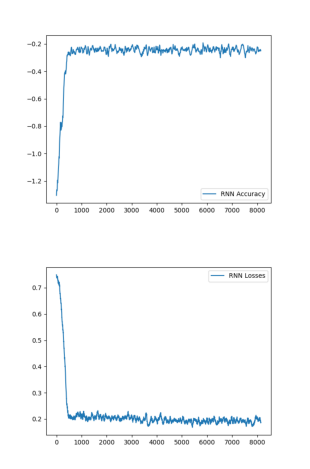

In [27]:
# fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig, axes = plt.subplots(2, 1)
for i, path in enumerate(paths):
    acc_path = f'{path}/figures/acc.png'
    loss_path = f'{path}/figures/loss.png'

    acc_img = plt.imread(acc_path)
    loss_img = plt.imread(loss_path)

    axes[0].imshow(acc_img)
    axes[0].axis('off')

    axes[1].imshow(loss_img)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Parameter Recovery

The following plots show the stepwise drift and diffusion values that the RNNs have learned. Each are taken from the first sequence. The threshold is also plotted for convenience.

### Load Models

First, we need to load the trained RNNs and their corresponding RTs. The RTs are used to simulate the same number of choice-RTs from the RNNs and later plot real and predicted RT distributions.

In [28]:
def load_rnn_regressor(experiment, pos_encoding=True, device='cpu', min_dt=0.01, ln_dim=1):
    # Set paths
    checkpoint_load_path = f'{experiment}/checkpoint.pth'
    rt_load_path = f'{experiment}/rt.npy'
    config_file_path = f'{experiment}/config.yml'

    # Load config file
    with open(config_file_path, "r") as file:
        config = yaml.safe_load(file)

    rts_original = np.load(rt_load_path)
    t_max = np.max(abs(rts_original))

    rnn_regressor = RNNRegressor(hidden_dim=config['rnn_params']['hidden_dim'],
                                 hidden_layers=config['rnn_params']['hidden_layers'],
                                 lr=config['training_params']['lr'],
                                 batch_size=config['rnn_params']['batch_size'],
                                 train_interval=config['training_params']['train_interval'],
                                 init_evidence=0.,
                                 threshold=1.,
                                 t_max=t_max,
                                 checkpoint_load_path=checkpoint_load_path,
                                 save_path=None,
                                 device=device,
                                 logger=None,
                                 verbose=True,
                                 min_dt=min_dt,
                                 positional_encoding=pos_encoding)

    return rnn_regressor, rts_original, config, t_max

In [29]:
rnn_regressor_ddm, rts_original_ddm, config_ddm, t_max_ddm = load_rnn_regressor(path_ddm, False)
rnn_regressor_ugm, rts_original_ugm, config_ugm, t_max_ugm = load_rnn_regressor(path_ugm, False)
rnn_regressor_nonlinear, rts_original_nonlinear, config_nonlinear, t_max_nonlinear = load_rnn_regressor(path_nonlinear, False)

Loaded checkpoint from experiments/constant_nogan_mae_lrsch_fineq/20251119-131024/checkpoint.pth
Loaded checkpoint from experiments/linear_nogan_mae_lrsch_fineq/20251119-140631/checkpoint.pth
Loaded checkpoint from experiments/nonlinear_nogan_mae_lrsch_fineq/20251119-150653/checkpoint.pth


### Simulate RTs from RNNs

In [44]:
# rts_rnn_ddm, traces_rnn_ddm, dt_rnn_ddm, decision_indices_ddm = rnn_regressor_ddm.predict(np.zeros(len(rts_original_ddm)))
# rts_rnn_ugm, traces_rnn_ugm, dt_rnn_ugm, decision_indices_ugm = rnn_regressor_ugm.predict(np.zeros(len(rts_original_ugm)))
# rts_rnn_nonlinear, traces_rnn_nonlinear, dt_rnn_nonlinear, decision_indices_nonlinear = rnn_regressor_nonlinear.predict(np.zeros(len(rts_original_nonlinear)))
rts_rnn_ddm, traces_rnn_ddm, dt_rnn_ddm, decision_indices_ddm = rnn_regressor_ddm.predict(np.full((8192 * 2, 100, 1), 1), warmup=5)
rts_rnn_ugm, traces_rnn_ugm, dt_rnn_ugm, decision_indices_ugm = rnn_regressor_ugm.predict(np.full((8192 * 2, 100, 1), 1), warmup=5)
rts_rnn_nonlinear, traces_rnn_nonlinear, dt_rnn_nonlinear, decision_indices_nonlinear = rnn_regressor_nonlinear.predict(np.full((8192 * 2, 100, 1), 1), warmup=5)

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


In [45]:
rts_rnn_ddm = rts_rnn_ddm.reshape(-1, 1)
rts_rnn_ugm = rts_rnn_ugm.reshape(-1, 1)
rts_rnn_nonlinear = rts_rnn_nonlinear.reshape(-1, 1)

### Stepwise Drift and Diffusion Plots

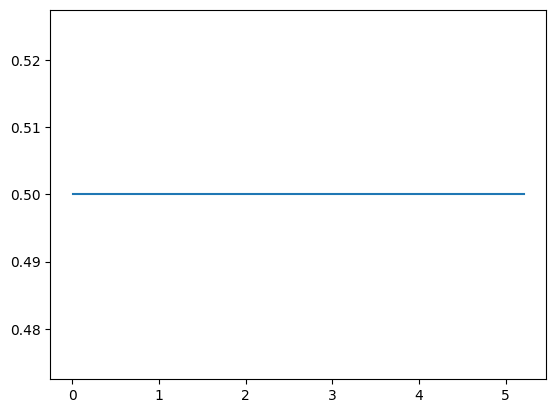

In [47]:
ddm_drifts_function = lambda mu, t: mu + 0*t
# t = np.array(all_t)
# t = np.cumsum(np.append(0.2, [dt_rnn_ugm] * 99))
step_size = int(np.ceil(t_max_ddm / dt_rnn_ddm[0].item()))
t_ddm = np.cumsum([dt_rnn_ddm] * step_size)
mu = config_ddm['ddm_params']['drift']
ddm_drifts = ddm_drifts_function(mu, t_ddm)
plt.plot(t_ddm, ddm_drifts)
plt.show()

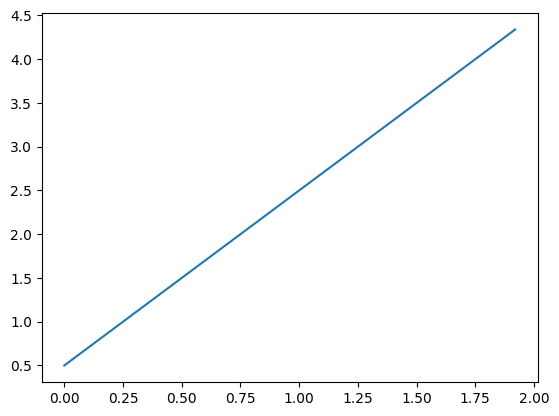

In [49]:
lin_drifts_function = lambda mu, t: mu + t * 2
# t = np.array(all_t) 
step_size = int(np.ceil(t_max_ugm / dt_rnn_ugm[0].item()))
t = np.cumsum(np.append(0.0, [dt_rnn_ugm] * step_size))
# t = np.cumsum([dt_rnn_ugm] * 100)
mu = config_ugm['ddm_params']['drift']
lin_drifts = lin_drifts_function(mu, t)
plt.plot(t, lin_drifts)
plt.show()

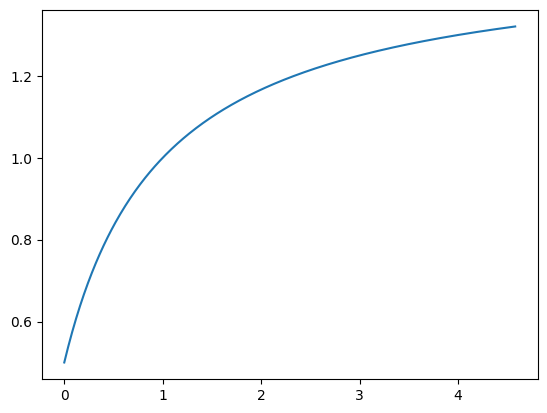

In [50]:
nonlin_drifts_function = lambda mu, t: mu + t / (1.0 + t)
# t = np.linspace(0, t_max_nonlinear, 100)
# t = np.array(all_t) 
# t = np.cumsum(np.append(0.2, [dt_rnn_nonlinear] * 99))
step_size = int(np.ceil(t_max_nonlinear / dt_rnn_nonlinear[0].item()))
t = np.cumsum(np.append(0.0, [dt_rnn_nonlinear] * step_size)) 
mu = config_nonlinear['ddm_params']['drift']
nonlin_drifts = nonlin_drifts_function(mu, t)
plt.plot(t, nonlin_drifts)
plt.show()


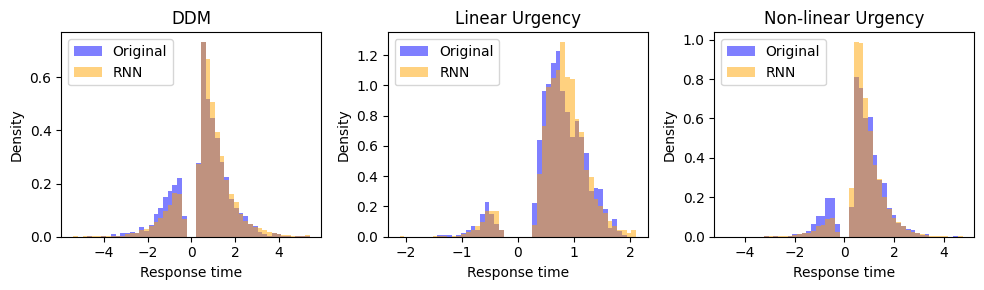

In [51]:
def plot_rts(rt_dicts):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes = axes.flatten()

    for ax, rt_dict in zip(axes, rt_dicts):

        plot_rts_multi(ax, rt_dict)
        ax.set_title(rt_dict['label'])

        # ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    plt.tight_layout()
    plt.show()
    plt.close()

rt_dicts = [
    {
        'rts': [rts_original_ddm, rts_rnn_ddm],
        'labels': ['Original', 'RNN'],
        'colors': ['blue', 'orange'],
        'label': 'DDM'
    },
    {
        'rts': [rts_original_ugm, rts_rnn_ugm],
        'labels': ['Original', 'RNN'],
        'colors': ['blue', 'orange'],
        'label': 'Linear Urgency'
    },
    {
        'rts': [rts_original_nonlinear, rts_rnn_nonlinear],
        'labels': ['Original', 'RNN'],
        'colors': ['blue', 'orange'],
        'label': 'Non-linear Urgency'
    }
]

plot_rts(rt_dicts)

idx: 0, seq: 173 size: (521,)
idx: 0, seq: 93 size: (192,)
idx: 0, seq: 87 size: (458,)


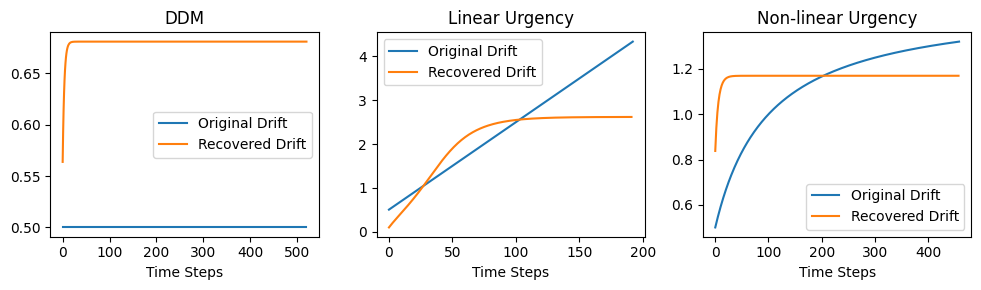

In [53]:
def plot_traces(traces_dict):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes = axes.flatten()

    for ax, (label, (rnn_regressor, traces, decision_indices, original_drifts)) in zip(axes, traces_dict.items()):
        # idx = np.argmax(decision_indices)
        idx = 0
        # seq = traces['evidence'][idx].size
        seq = decision_indices[idx]
        print(f"idx: {idx}, seq: {seq} size: {traces['drift'][idx].shape}")
        drifts = traces['drift'][idx]
        diffusions = traces['diffusion'][idx]
        # drifts = drifts / diffusions
        # threshold = rnn_regressor.rnn.threshold.detach().cpu().numpy()
        # originals = nonlin_drifts_function(0.5, t)

        ax.plot(original_drifts, label='Original Drift')
        ax.plot(drifts, label='Recovered Drift')
        # ax.plot(diffusions, label='Diffusion Traces (idx: 0)')
        # ax.plot(np.full(drifts.shape, threshold), label='Threshold')
        ax.set_title(label)
        ax.set_xlabel('Time Steps')
        ax.legend()

        # ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    # Hide the last empty subplot
    if len(traces_dict) < len(axes):
        for ax in axes[len(traces_dict):]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

traces_dict = {
    "DDM": [rnn_regressor_ddm, traces_rnn_ddm, decision_indices_ddm, ddm_drifts],
    "Linear Urgency": [rnn_regressor_ugm, traces_rnn_ugm, decision_indices_ugm, lin_drifts],
    "Non-linear Urgency": [rnn_regressor_nonlinear, traces_rnn_nonlinear, decision_indices_nonlinear, nonlin_drifts]
}

plot_traces(traces_dict)

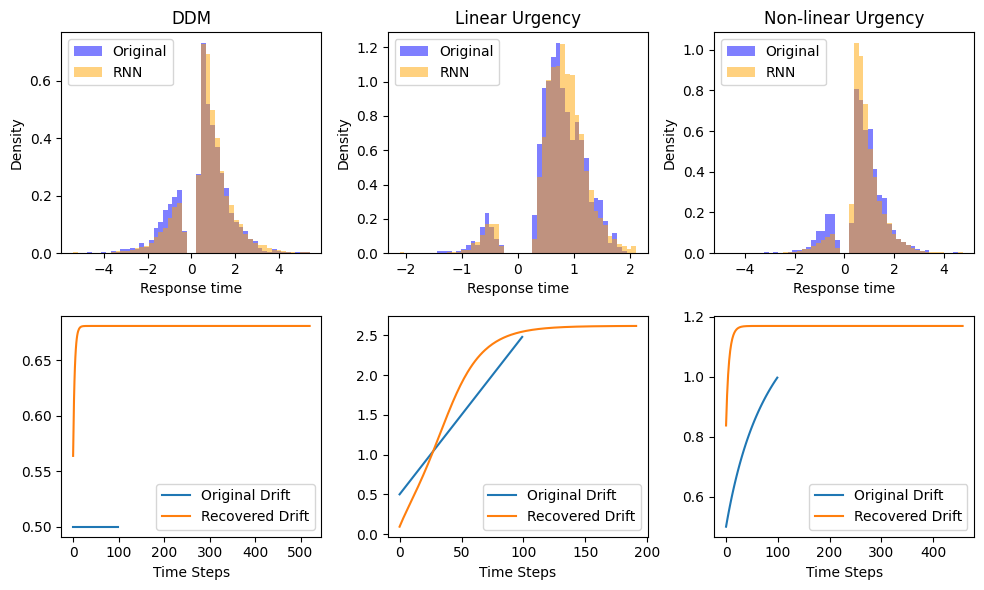

In [37]:
def plot_combined(rt_dicts, traces_dict):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    top_axes = axes[0]
    middle_axes = axes[1]
    # bottom_axes = axes[2]

    # Top row: reuse the same logic as in plot_rts
    for ax, rt_dict in zip(top_axes, rt_dicts):
        plot_rts_multi(ax, rt_dict)
        ax.set_title(rt_dict['label'])

    # Bottom row: reuse the same logic as in plot_traces
    for ax, (label, (rnn_regressor, traces, decision_indices, original_drifts)) in zip(middle_axes, traces_dict.items()):
        idx = np.argmax(decision_indices)
        seq = decision_indices[idx]
        drifts = traces['drift'][idx]
        diffusions = traces['diffusion'][idx]
        # drifts = drifts / diffusions

        ax.plot(original_drifts, label='Original Drift')
        ax.plot(drifts, label='Recovered Drift')
        # ax.plot(diffusions, label='Diffusion Traces')
        # ax.plot(np.full(drifts.shape, 1.0), label='Original Diffusion',)
        # ax.set_title(label)
        ax.set_xlabel('Time Steps')
        ax.legend()

    # for ax, (label, (rnn_regressor, traces, decision_indices, original_drifts)) in zip(bottom_axes, traces_dict.items()):
    #     ax.plot(diffusions, label='Diffusion Traces')
    #     ax.plot(np.full(drifts.shape, 1.0), label='Original Diffusion')
    #     # ax.set_title(label)
    #     ax.set_xlabel('Time Steps')
    #     ax.legend()        

    plt.tight_layout()
    plt.show()
    plt.close()

plot_combined(rt_dicts, traces_dict)

In [14]:
import pandas as pd

def create_df(traces_dict):
    data = {
        'Drift Mean': [],
        'Drift Std': [],
        'Diffusion Mean': [],
        'Diffusion Std': [],
        'Drift / Diffusion': []
    }

    for label, (rnn_regressor, traces, _, _) in traces_dict.items():
        drift_means = []
        drift_stds = []
        diffusion_means = []
        diffusion_stds = []
        for idx in range(len(traces['evidence'])):
            seq = traces['evidence'][idx].size
            drifts = traces['drift'][idx, :seq]
            diffusions = traces['diffusion'][idx, :seq]

            drift_means.append(np.mean(drifts))
            drift_stds.append(np.std(drifts))
            diffusion_means.append(np.mean(diffusions))
            diffusion_stds.append(np.std(diffusions))

        data['Drift Mean'].append(np.mean(drift_means))
        data['Drift Std'].append(np.mean(drift_stds))
        data['Diffusion Mean'].append(np.mean(diffusion_means))
        data['Diffusion Std'].append(np.mean(diffusion_stds))
        data['Drift / Diffusion'].append(np.mean(drift_means) / np.mean(diffusion_means))

    df = pd.DataFrame(data, index=traces_dict.keys())
    return df

In [15]:
df = create_df(traces_dict)

In [16]:
df

,Drift Mean,Drift Std,Diffusion Mean,Diffusion Std,Drift / Diffusion
DDM,0.416314,2.980232e-08,1.0,0.0,0.416314
Linear Urgency,1.025658,8.463904e-08,1.0,0.0,1.025658
Non-linear Urgency,2.099270,2.384186e-07,1.0,0.0,2.099270


### Fit SINDy model

The following code fits a SINDy model to the drift and diffusion values of the RNNs. The SINDy model is a sparse regression model that learns the underlying dynamics of the system. The SINDy model is fitted to the drift and diffusion values of the RNNs and the discovered equation is displayed.

In [17]:
from math import comb

n_polynomial_combinations = np.array([comb(2 + d, d) for d in range(3)])
thresholds = np.zeros((1, n_polynomial_combinations[-1]))
index = 0
for d in range(len(n_polynomial_combinations)):
    thresholds[0, index:n_polynomial_combinations[d]] = d * 0.05
    index = n_polynomial_combinations[d]

In [18]:
thresholds

array([[0.  , 0.05, 0.05, 0.1 , 0.1 , 0.1 ]])

In [19]:
thresholds = np.array([thresholds[0, 1:]])

In [20]:
import pysindy as ps
library = ps.PolynomialLibrary(2)

# times = [np.arange(len(traces_rnn_ugm['drift'][i]))  / 0.01 for i in range(len(traces_rnn_ugm['drift']))]
def get_sindy_model(dt_rnn, threshold=0.05, fit_intercept=False):
    # t = np.cumsum(np.append(0, [dt_rnn] * 99))

    sindy_drift = ps.SINDy(
        optimizer=ps.SR3(verbose=False, threshold=threshold, thresholds = thresholds, fit_intercept=fit_intercept, thresholder="weighted_l1", max_iter=100),
        feature_library=library,
        discrete_time=True,
        feature_names=['v', 't'],
        t_default=dt_rnn[0].item(),
        differentiation_method=ps.SmoothedFiniteDifference(),
    )

    sindy_diffusion = ps.SINDy(
        optimizer=ps.StableLinearSR3(verbose=False, threshold=threshold, fit_intercept=False), #thresholder="L1"),
        feature_library=library,
        discrete_time=True,
        feature_names=['sigma', 't'],
        t_default=dt_rnn[0].item(),
        differentiation_method=ps.SmoothedFiniteDifference(),
    )
    return sindy_drift, sindy_diffusion


In [22]:
drift_traces_ugm = traces_rnn_ugm['drift'][0]
# diffusion_traces_ugm = traces_rnn_ugm['diffusion'][0][50:]
diffusion_traces_ugm = np.full((drift_traces_ugm.shape[0], 1), 1.)
# t = [t_ugm] * len(drift_traces)
t_ugm = np.full((drift_traces_ugm.shape[0], 1), dt_rnn_ugm[0])
t_ugm = np.cumsum(np.append(0., t_ugm[:-1]))
t_ugm = np.arange(drift_traces_ugm.shape[0])

sindy_drift_ugm, sindy_diffusion_ugm = get_sindy_model(dt_rnn_ugm, threshold=0.05, fit_intercept=False)
sindy_drift_ugm.fit(drift_traces_ugm,
        #   u=[t for t in np.stack([diffusion_traces, t_big], axis=-1)],
          u = t_ugm,
        #   u = np.stack([drift_traces_ugm, t_ugm], axis=-1),
          ensemble=True,
          library_ensemble=True,
          multiple_trajectories=False,
          t=t_ugm
          )
# sindy_diffusion_ugm.fit(diffusion_traces_ugm,
#         #   u=[t for t in np.stack([diffusion_traces, t_big], axis=-1)],
#           u = t_ugm,
#           ensemble=False,
#           library_ensemble=False,
#           multiple_trajectories=False,
#           t=t_ugm)


/Users/imtezcan/.pyenv/versions/3.11.0/envs/ai4sci/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 100 iterations.
  warnings.warn(
/Users/imtezcan/.pyenv/versions/3.11.0/envs/ai4sci/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 100 iterations.
  warnings.warn(
/Users/imtezcan/.pyenv/versions/3.11.0/envs/ai4sci/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 100 iterations.
  warnings.warn(
/Users/imtezcan/.pyenv/versions/3.11.0/envs/ai4sci/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 100 iterations.
  warnings.warn(
/Users/imtezcan/.pyenv/versions/3.11.0/envs/ai4sci/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 100 iterations.
  warnings.warn(
/User

SINDy(differentiation_method=SmoothedFiniteDifference(), discrete_time=True,
      feature_library=PolynomialLibrary(), feature_names=['v', 't'],
      optimizer=SR3(max_iter=100, threshold=0.05, thresholder='weighted_l1',
                    thresholds=array([[0.05, 0.05, 0.1 , 0.1 , 0.1 ]])),
      t_default=0.009999998845160007)

In [23]:
sindy_drift_ugm.print()
# sindy_diffusion_ugm.print()

(v)[k+1] = 2.035 1 + -0.984 v[k]


(v)[k+1] = 0.110 1 + 0.920 v[k]

In [24]:
v = mu + t * 2

In [25]:
dt_rnn_ugm[0] *2

0.019999997690320015

In [26]:
x_0 = traces_rnn_ugm['drift'][0][0]
x = x_0
x_arr = []
for i in range(100):
    # print(np.array([x]).shape)
    x = sindy_drift_ugm.predict(np.array([x]), u=np.array([t_ugm[i]]))[0][0]
    x_arr.append(x)

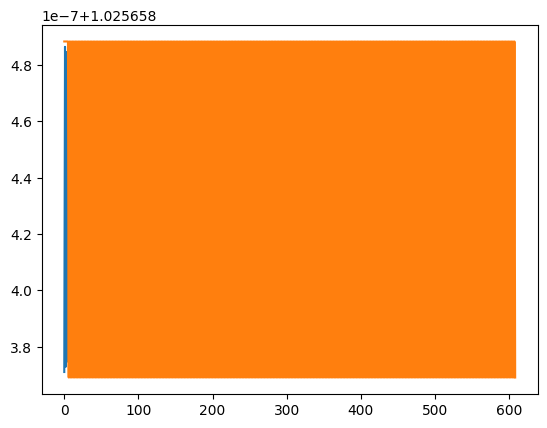

In [27]:
plt.plot(x_arr)
plt.plot(traces_rnn_ugm['drift'][0])
plt.show()

### Predict from SINDy

Now that we have fitted the SINDy model, we can use it to predict stepwise drift and diffusion values. We will also calculate new choice-RTs from the SINDy model, which we will use later for model recovery and comparison.

In [28]:
def sindy_predict(sindy_drift, sindy_diffusion, initial_v=0.5, initial_D=1.0, b=1.0, tnd=0.2, n_sims=8192, dt=0.001):
    rts = []

    for _ in range(n_sims):
        v_t = initial_v
        D_t = initial_D
        x = 0
        t_scalar = 0
        while abs(x) < b:
            v_in = np.array([[v_t]])      # shape (1, 1)
            D_in = np.array([[D_t]])      # shape (1, 1)
            u_in = np.array([[t_scalar]]) # shape (1, 1)

            v_t = sindy_drift.predict(v_in, u=u_in, multiple_trajectories=False).squeeze()
            D_t = sindy_diffusion.predict(D_in, u=u_in, multiple_trajectories=False).squeeze()

            x += v_t * dt + D_t * np.sqrt(dt) * np.random.randn()
            t_scalar += dt
        rts.append((tnd + dt * (t_scalar / dt)) * np.sign(x))

    return rts

In [29]:
def sindy_predict_fast(sindy_drift, sindy_diffusion,
                       initial_v=0.5, initial_D=1.0,
                       b=1.0, tnd=0.2, n_sims=8192, dt=0.02,
                       max_steps=100, seed=None):
    rng = np.random.default_rng(seed)

    v = np.full(n_sims, initial_v, dtype=float)
    D = np.full(n_sims, initial_D, dtype=float)
    x = np.zeros(n_sims, dtype=float)
    t = np.zeros(n_sims, dtype=float)
    all_v = [initial_v]
    all_D = [initial_D]

    done = np.zeros(n_sims, dtype=bool)
    rts = np.empty(n_sims, dtype=float)

    for _ in range(max_steps):
        active = ~done
        if not np.any(active):
            break

        v_in = v[active][:, None]  # (n_active, 1)
        D_in = D[active][:, None]  # (n_active, 1)
        u_in = t[active][:, None]  # (n_active, 1)

        v_next = sindy_drift.predict(v_in, u=u_in, multiple_trajectories=False).ravel()
        # D_next = sindy_diffusion.predict(D_in, u=u_in, multiple_trajectories=False).ravel()
        D_next = 1.0

        all_v.append(v_next[0])
        all_D.append(1.0)

        noise = rng.standard_normal(v_next.shape[0])
        x[active] += v_next * dt + D_next * np.sqrt(dt) * noise
        t[active] += dt
        v[active] = v_next
        D[active] = D_next

        crossed = (np.abs(x) >= b) & active
        if np.any(crossed):
            rts[crossed] = (tnd + t[crossed]) * np.sign(x[crossed])
            done[crossed] = True

    # If any didn’t cross by max_steps, record the current time (optional)
    if np.any(~done):
        pending = ~done
        rts[pending] = (tnd + t[pending]) * np.sign(x[pending])

    return rts, all_v, all_D

In [30]:
v_init_ugm = traces_rnn_ugm['drift'][0][0]
D_init_ugm = 1.0#traces_rnn_ugm['diffusion'][0][0]

In [31]:
# rts_sindy_ddm, vs_sindy_ddm, Ds_sindy_ddm = sindy_predict_fast(sindy_drift_ddm, sindy_diffusion_ddm, initial_v=v_init_ddm, initial_D=D_init_ddm, b=rnn_regressor_ddm.rnn.threshold.item(), dt=dt_rnn_ddm[0])
rts_sindy_ugm, vs_sindy_ugm, Ds_sindy_ugm = sindy_predict_fast(sindy_drift_ugm, sindy_diffusion_ugm, initial_v=v_init_ugm, initial_D=D_init_ugm, b=rnn_regressor_ugm.rnn.threshold.item(), dt=dt_rnn_ugm[0])
# rts_sindy_nonlinear, vs_sindy_nonlinear, Ds_sindy_nonlinear = sindy_predict_fast(sindy_drift_nonlinear, sindy_diffusion_nonlinear, initial_v=v_init_nonlinear, initial_D=D_init_nonlinear, b=rnn_regressor_nonlinear.rnn.threshold.item(), dt=dt_rnn_nonlinear[0])

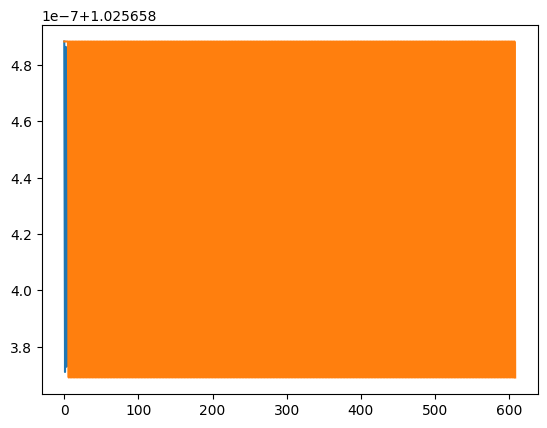

In [32]:
# Plot vs_sindy_ugm
plt.plot(vs_sindy_ugm)
plt.plot(drift_traces_ugm)
plt.show()

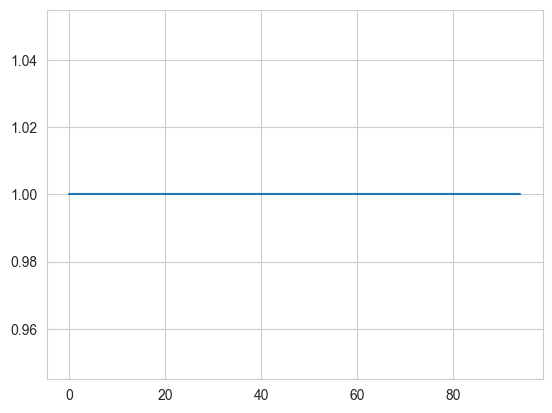

In [94]:
# Plot vs_sindy_ugm
plt.plot(Ds_sindy_ugm)
plt.show()

In [95]:
# rts_sindy_ddm = np.array(rts_sindy_ddm).reshape(-1, 1)
rts_sindy_ugm = np.array(rts_sindy_ugm).reshape(-1, 1)
# rts_sindy_nonlinear = np.array(rts_sindy_nonlinear).reshape(-1, 1)

### Plot Response Time Distributions from RNN and SINDy

Below we plot the response time distributions from the RNN and SINDy models, as well as the original RTs from the PyBeam model. The distributions are plotted as histograms.

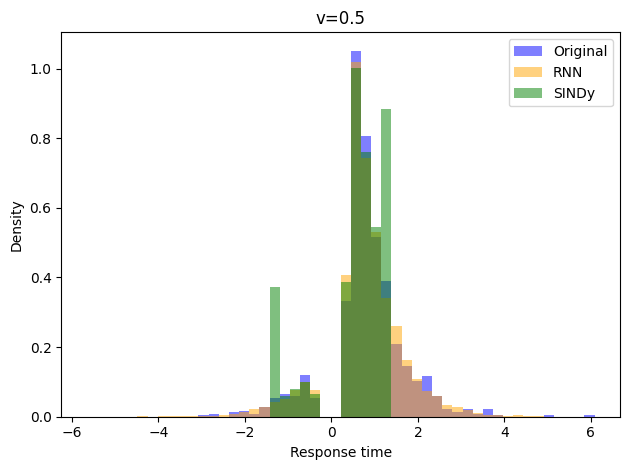

In [33]:
fig, ax = plt.subplots()

rt_dicts = [
    {
        'rts': [rts_original_ugm, rts_rnn_ugm, rts_sindy_ugm],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=0.5'
    }
]

plot_rts_multi(ax, rt_dicts[0])
ax.set_title(rt_dicts[0]['label'])

plt.tight_layout()
plt.show()
plt.close()

In [35]:
drift_traces_ddm = traces_rnn_ddm['drift'][0]
# diffusion_traces_ugm = traces_rnn_ugm['diffusion'][0][50:]
diffusion_traces_ddm = np.full((drift_traces_ddm.shape[0], 1), 1.)
# t = [t_ugm] * len(drift_traces)
t_ddm = np.full((drift_traces_ddm.shape[0], 1), dt_rnn_ddm[0])
t_ddm = np.cumsum(np.append(0., t_ddm[:-1]))
t_ddm = np.arange(drift_traces_ddm.shape[0])

sindy_drift_ddm, sindy_diffusion_ddm = get_sindy_model(dt_rnn_ddm, threshold=0.05, fit_intercept=False)
sindy_drift_ddm.fit(drift_traces_ddm,
        #   u=[t for t in np.stack([diffusion_traces, t_big], axis=-1)],
          u = t_ddm,
        #   u = np.stack([drift_traces_ugm, t_ugm], axis=-1),
          ensemble=True,
          library_ensemble=True,
          multiple_trajectories=False,
          t=t_ddm
          )
# sindy_diffusion_ugm.fit(diffusion_traces_ugm,
#         #   u=[t for t in np.stack([diffusion_traces, t_big], axis=-1)],
#           u = t_ugm,
#           ensemble=False,
#           library_ensemble=False,
#           multiple_trajectories=False,
#           t=t_ugm)

SINDy(differentiation_method=SmoothedFiniteDifference(), discrete_time=True,
      feature_library=PolynomialLibrary(), feature_names=['v', 't'],
      optimizer=SR3(max_iter=100, threshold=0.05, thresholder='weighted_l1',
                    thresholds=array([[0.05, 0.05, 0.1 , 0.1 , 0.1 ]])),
      t_default=0.009999999776482582)

In [36]:
sindy_drift_ddm.print()

(v)[k+1] = 0.416 1


In [37]:
x_0_ddm = traces_rnn_ddm['drift'][0][0]
x_ddm = x_0_ddm
x_arr_ddm = []
for i in range(100):
    # print(np.array([x]).shape)
    x_ddm = sindy_drift_ddm.predict(np.array([x_ddm]), u=np.array([t_ddm[i]]))[0][0]
    x_arr_ddm.append(x_ddm)

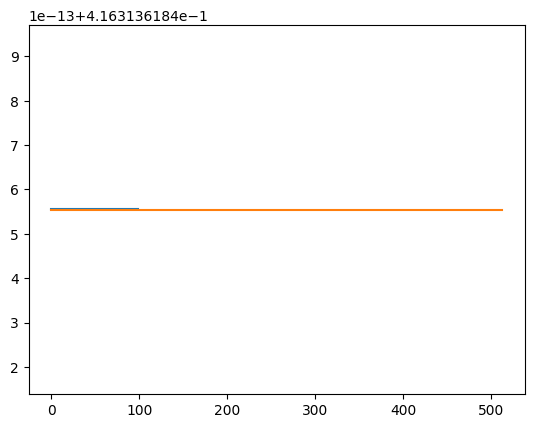

In [38]:
plt.plot(x_arr_ddm)
plt.plot(traces_rnn_ddm['drift'][0])
plt.show()

In [44]:
drift_traces_nonlinear = traces_rnn_nonlinear['drift'][0]
# diffusion_traces_ugm = traces_rnn_ugm['diffusion'][0][50:]
diffusion_traces_nonlinear = np.full((drift_traces_nonlinear.shape[0], 1), 1.)
# t = [t_ugm] * len(drift_traces)
t_nonlinear = np.full((drift_traces_nonlinear.shape[0], 1), dt_rnn_nonlinear[0])
t_nonlinear = np.cumsum(np.append(0., t_nonlinear[:-1]))
t_nonlinear = np.arange(drift_traces_nonlinear.shape[1])

sindy_drift_nonlinear, sindy_diffusion_nonlinear = get_sindy_model(dt_rnn_nonlinear, threshold=0.05, fit_intercept=False)
sindy_drift_nonlinear.fit(drift_traces_nonlinear,
        #   u=[t for t in np.stack([diffusion_traces, t_big], axis=-1)],
          u = t_nonlinear,
        #   u = np.stack([drift_traces_ugm, t_ugm], axis=-1),
          ensemble=True,
          library_ensemble=True,
          multiple_trajectories=False,
          t=t_nonlinear
          )
# sindy_diffusion_ugm.fit(diffusion_traces_ugm,
#         #   u=[t for t in np.stack([diffusion_traces, t_big], axis=-1)],
#           u = t_ugm,
#           ensemble=False,
#           library_ensemble=False,
#           multiple_trajectories=False,
#           t=t_ugm)

IndexError: tuple index out of range

v = mu + t / (1.0 + t)

0.57


In [41]:
sindy_drift_nonlinear.print()

(v)[k+1] = 0.476 v[k]^2


In [42]:
x_0_nonlinear = traces_rnn_nonlinear['drift'][0][0]
x_nonlinear = x_0_nonlinear
# x_0_nonlinear = 0.0
x_arr_nonlinear = []
for i in range(100):
    # print(np.array([x]).shape)
    x_nonlinear = sindy_drift_nonlinear.predict(np.array([x_nonlinear]), u=np.array([t_nonlinear[i]]))[0][0]
    x_arr_nonlinear.append(x_nonlinear)

Original Equation:


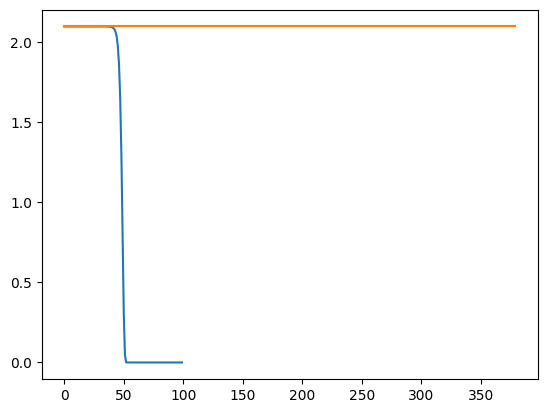

In [43]:
plt.plot(x_arr_nonlinear)
plt.plot(traces_rnn_nonlinear['drift'][0])
plt.show()

In [105]:
v_init_ddm = traces_rnn_ddm['drift'][0][50]
D_init_ddm = traces_rnn_ddm['diffusion'][0][50]
v_init_ugm = traces_rnn_ugm['drift'][0][0]
D_init_ugm = 1.0#traces_rnn_ugm['diffusion'][0][0]
v_init_nonlinear = traces_rnn_nonlinear['drift'][0][0]
D_init_nonlinear = 1.0#traces_rnn_nonlinear['diffusion'][0][0]

In [106]:
rts_sindy_ddm, vs_sindy_ddm, Ds_sindy_ddm = sindy_predict_fast(sindy_drift_ddm, sindy_diffusion_ddm, initial_v=v_init_ddm, initial_D=D_init_ddm, b=rnn_regressor_ddm.rnn.threshold.item(), dt=dt_rnn_ddm[0])
rts_sindy_ugm, vs_sindy_ugm, Ds_sindy_ugm = sindy_predict_fast(sindy_drift_ugm, sindy_diffusion_ugm, initial_v=v_init_ugm, initial_D=D_init_ugm, b=rnn_regressor_ugm.rnn.threshold.item(), dt=dt_rnn_ugm[0])
rts_sindy_nonlinear, vs_sindy_nonlinear, Ds_sindy_nonlinear = sindy_predict_fast(sindy_drift_nonlinear, sindy_diffusion_nonlinear, initial_v=v_init_nonlinear, initial_D=D_init_nonlinear, b=rnn_regressor_nonlinear.rnn.threshold.item(), dt=dt_rnn_nonlinear[0])

In [107]:
rts_sindy_ddm = np.array(rts_sindy_ddm).reshape(-1, 1)
rts_sindy_ugm = np.array(rts_sindy_ugm).reshape(-1, 1)
rts_sindy_nonlinear = np.array(rts_sindy_nonlinear).reshape(-1, 1)

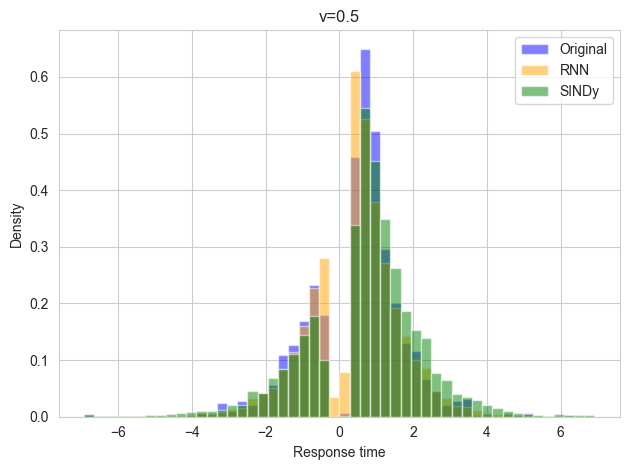

In [108]:
fig, ax = plt.subplots()

rt_dicts = [
    {
        'rts': [rts_original_ddm, rts_rnn_ddm, rts_sindy_ddm],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=0.5'
    }
]

plot_rts_multi(ax, rt_dicts[0])
ax.set_title(rt_dicts[0]['label'])

plt.tight_layout()
plt.show()
plt.close()

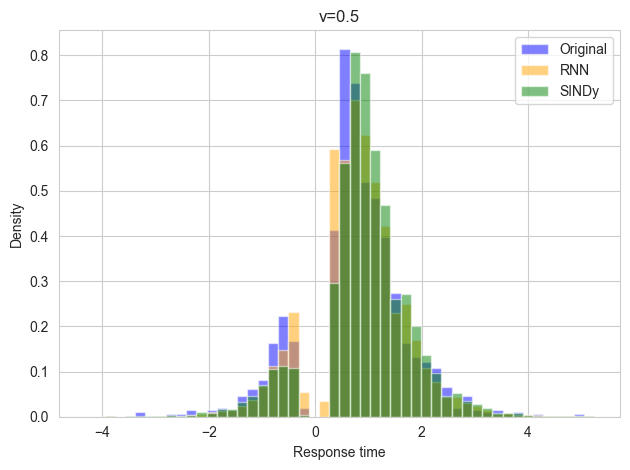

In [109]:
fig, ax = plt.subplots()

rt_dicts = [
    {
        'rts': [rts_original_nonlinear, rts_rnn_nonlinear, rts_sindy_nonlinear],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=0.5'
    }
]

plot_rts_multi(ax, rt_dicts[0])
ax.set_title(rt_dicts[0]['label'])

plt.tight_layout()
plt.show()
plt.close()

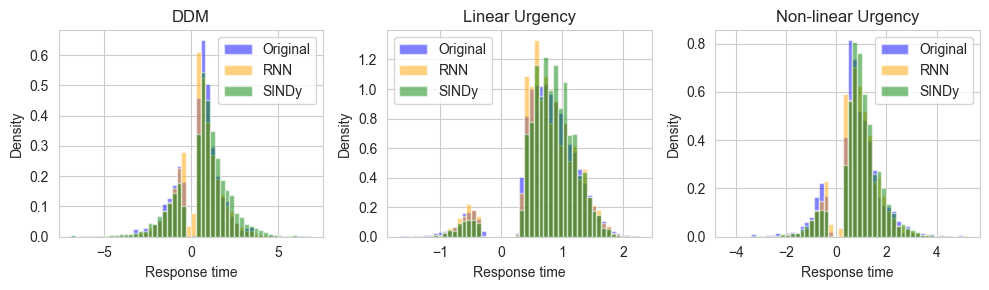

In [110]:
def plot_rts(rt_dicts):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes = axes.flatten()

    for ax, rt_dict in zip(axes, rt_dicts):

        plot_rts_multi(ax, rt_dict)
        ax.set_title(rt_dict['label'])

        # ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    plt.tight_layout()
    plt.show()
    plt.close()

rt_dicts = [
    {
        'rts': [rts_original_ddm, rts_rnn_ddm, rts_sindy_ddm],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'DDM'
    },
    {
        'rts': [rts_original_ugm, rts_rnn_ugm, rts_sindy_ugm],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'Linear Urgency'
    },
    {
        'rts': [rts_original_nonlinear, rts_rnn_nonlinear, rts_sindy_nonlinear],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'Non-linear Urgency'
    }
]

plot_rts(rt_dicts)

idx: 1163, seq: 99
idx: 2182, seq: 85
idx: 5619, seq: 99


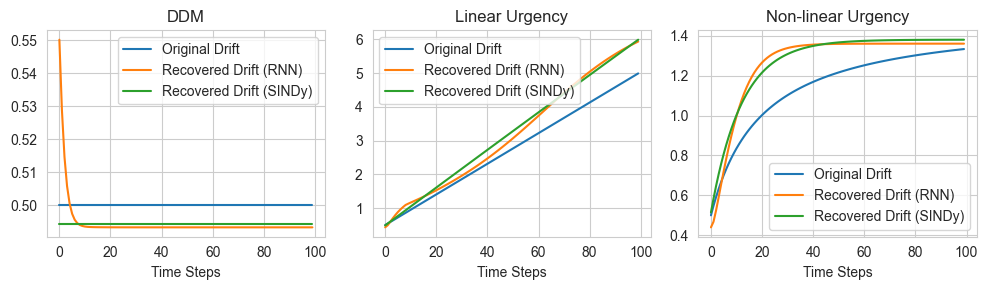

In [111]:
def plot_traces(traces_dict):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes = axes.flatten()

    for ax, (label, (rnn_regressor, traces, decision_indices, original_drifts, sindy_drifts)) in zip(axes, traces_dict.items()):
        idx = np.argmax(decision_indices)
        # idx = 0
        # seq = traces['evidence'][idx].size
        seq = decision_indices[idx]
        print(f"idx: {idx}, seq: {seq}")
        drifts = traces['drift'][idx]
        diffusions = traces['diffusion'][idx]
        # drifts = drifts / diffusions
        # threshold = rnn_regressor.rnn.threshold.detach().cpu().numpy()
        # originals = nonlin_drifts_function(0.5, t)

        ax.plot(original_drifts, label='Original Drift')
        ax.plot(drifts, label='Recovered Drift (RNN)')
        ax.plot(sindy_drifts, label='Recovered Drift (SINDy)')
        # ax.plot(diffusions, label='Diffusion Traces (idx: 0)')
        # ax.plot(np.full(drifts.shape, threshold), label='Threshold')
        ax.set_title(label)
        ax.set_xlabel('Time Steps')
        ax.legend()

        # ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    # Hide the last empty subplot
    if len(traces_dict) < len(axes):
        for ax in axes[len(traces_dict):]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

traces_dict = {
    "DDM": [rnn_regressor_ddm, traces_rnn_ddm, decision_indices_ddm, [0.5] * 100, x_arr_ddm],
    "Linear Urgency": [rnn_regressor_ugm, traces_rnn_ugm, decision_indices_ugm, lin_drifts, x_arr],
    "Non-linear Urgency": [rnn_regressor_nonlinear, traces_rnn_nonlinear, decision_indices_nonlinear, nonlin_drifts, x_arr_nonlinear]
}

plot_traces(traces_dict)

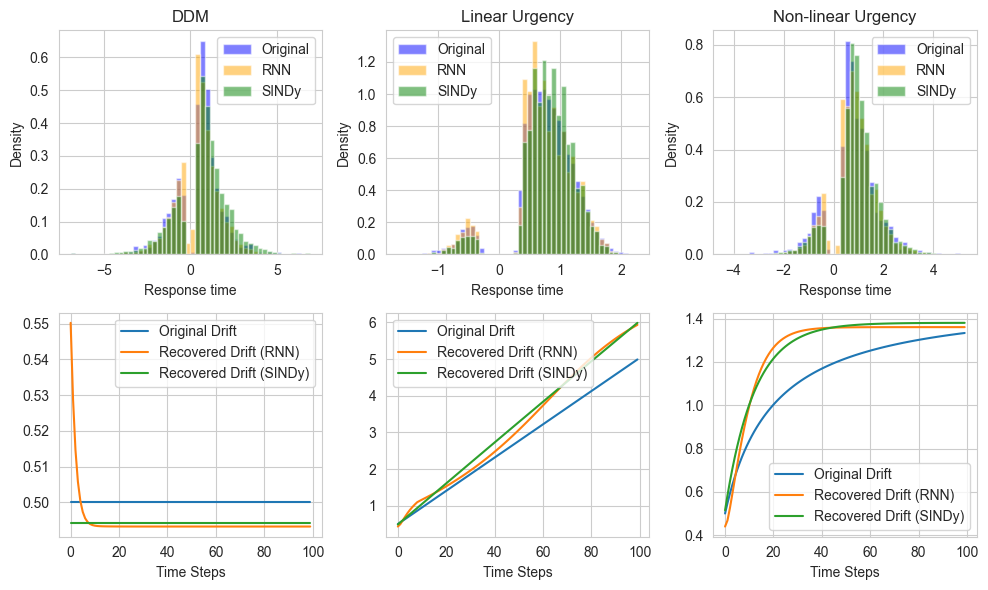

In [112]:
def plot_combined(rt_dicts, traces_dict):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    top_axes = axes[0]
    middle_axes = axes[1]
    # bottom_axes = axes[2]

    # Top row: reuse the same logic as in plot_rts
    for ax, rt_dict in zip(top_axes, rt_dicts):
        plot_rts_multi(ax, rt_dict)
        ax.set_title(rt_dict['label'])

    # Bottom row: reuse the same logic as in plot_traces
    for ax, (label, (rnn_regressor, traces, decision_indices, original_drifts, sindy_drifts)) in zip(middle_axes, traces_dict.items()):
        idx = np.argmax(decision_indices)
        seq = decision_indices[idx]
        drifts = traces['drift'][idx]
        diffusions = traces['diffusion'][idx]
        # drifts = drifts / diffusions

        ax.plot(original_drifts, label='Original Drift')
        ax.plot(drifts, label='Recovered Drift (RNN)')
        ax.plot(sindy_drifts, label='Recovered Drift (SINDy)')
        # ax.plot(diffusions, label='Diffusion Traces')
        # ax.plot(np.full(drifts.shape, 1.0), label='Original Diffusion',)
        # ax.set_title(label)
        ax.set_xlabel('Time Steps')
        ax.legend()

    # for ax, (label, (rnn_regressor, traces, decision_indices, original_drifts)) in zip(bottom_axes, traces_dict.items()):
    #     ax.plot(diffusions, label='Diffusion Traces')
    #     ax.plot(np.full(drifts.shape, 1.0), label='Original Diffusion')
    #     # ax.set_title(label)
    #     ax.set_xlabel('Time Steps')
    #     ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

plot_combined(rt_dicts, traces_dict)

In [113]:
original_drifts_ddm = [0.5] * 100
sindy_drifts_ddm = x_arr_ddm
rnn_drifts_ddm = traces_rnn_ddm['drift'][0]

In [114]:
traces_dict = {
    "DDM": [rnn_regressor_ddm, traces_rnn_ddm, decision_indices_ddm, [0.5] * 100, x_arr_ddm],
    "Linear Urgency": [rnn_regressor_ugm, traces_rnn_ugm, decision_indices_ugm, lin_drifts, x_arr],
    "Non-linear Urgency": [rnn_regressor_nonlinear, traces_rnn_nonlinear, decision_indices_nonlinear, nonlin_drifts, x_arr_nonlinear]
}

In [115]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mse_mae_r2(traces_dict):
    for label, (rnn_regressor, traces, decision_indices, original_drifts, sindy_drifts) in traces_dict.items():
        # Assuming original_drifts, drifts, and sindy_drifts are numpy arrays
        # Calculate MSE
        rnn_drifts = traces['drift'][0]
        mse_drifts = mean_squared_error(original_drifts, rnn_drifts)
        mse_sindy = mean_squared_error(original_drifts, sindy_drifts)

        # Calculate MAE
        mae_drifts = mean_absolute_error(original_drifts, rnn_drifts)
        mae_sindy = mean_absolute_error(original_drifts, sindy_drifts)

        # Calculate R-squared
        r2_drifts = r2_score(original_drifts, rnn_drifts)
        r2_sindy = r2_score(original_drifts, sindy_drifts)

        # Print results
        print(f"{label} MSE (RNN): {mse_drifts}")
        print(f"{label} MSE(SINDy): {mse_sindy}")
        print(f"{label} MAE(RNN): {mae_drifts}")
        print(f"{label} MAE(SINDy): {mae_sindy}")
        print(f"{label} R-squared (RNN): {r2_drifts}")
        print(f"{label} R-squared (SINDy): {r2_sindy}")

In [116]:
mse_mae_r2(traces_dict)

DDM MSE (RNN): 7.78385191472708e-05
DDM MSE(SINDy): 3.422450306875774e-05
DDM MAE(RNN): 0.007288815379142761
DDM MAE(SINDy): 0.005850171199952845
DDM R-squared (RNN): 0.0
DDM R-squared (SINDy): 0.0
Linear Urgency MSE (RNN): 0.3193524595211639
Linear Urgency MSE(SINDy): 0.3406641556229839
Linear Urgency MAE(RNN): 0.4495723728835583
Linear Urgency MAE(SINDy): 0.5043215256907614
Linear Urgency R-squared (RNN): 0.8136288559379633
Linear Urgency R-squared (SINDy): 0.8011915470462326
Non-linear Urgency MSE (RNN): 0.023057077791263772
Non-linear Urgency MSE(SINDy): 0.02070183008929703
Non-linear Urgency MAE(RNN): 0.130370129561807
Non-linear Urgency MAE(SINDy): 0.1322764717847208
Non-linear Urgency R-squared (RNN): 0.4258630180788451
Non-linear Urgency R-squared (SINDy): 0.4845102941788666


In [117]:
import pandas as pd

def mse_mae_r2_to_df(traces_dict):
    results = {
        "Model": [],
        "Metric": [],
        "RNN": [],
        "SINDy": []
    }

    for label, (rnn_regressor, traces, decision_indices, original_drifts, sindy_drifts) in traces_dict.items():
        # Assuming original_drifts, drifts, and sindy_drifts are numpy arrays
        rnn_drifts = traces['drift'][0]

        # Calculate metrics
        mse_drifts = mean_squared_error(original_drifts, rnn_drifts)
        mse_sindy = mean_squared_error(original_drifts, sindy_drifts)
        mae_drifts = mean_absolute_error(original_drifts, rnn_drifts)
        mae_sindy = mean_absolute_error(original_drifts, sindy_drifts)
        r2_drifts = r2_score(original_drifts, rnn_drifts)
        r2_sindy = r2_score(original_drifts, sindy_drifts)

        # Append results to the dictionary
        results["Model"].extend([label] * 3)
        results["Metric"].extend(["MSE", "MAE", "R-squared"])
        results["RNN"].extend([mse_drifts, mae_drifts, r2_drifts])
        results["SINDy"].extend([mse_sindy, mae_sindy, r2_sindy])

    # Create a DataFrame
    df = pd.DataFrame(results)
    return df

# Example usage:
df = mse_mae_r2_to_df(traces_dict)
print(df)

                Model     Metric       RNN     SINDy
0                 DDM        MSE  0.000078  0.000034
1                 DDM        MAE  0.007289  0.005850
2                 DDM  R-squared  0.000000  0.000000
3      Linear Urgency        MSE  0.319352  0.340664
4      Linear Urgency        MAE  0.449572  0.504322
5      Linear Urgency  R-squared  0.813629  0.801192
6  Non-linear Urgency        MSE  0.023057  0.020702
7  Non-linear Urgency        MAE  0.130370  0.132276
8  Non-linear Urgency  R-squared  0.425863  0.484510


In [118]:
df

,Model,Metric,RNN,SINDy
0,DDM,MSE,0.000078,0.000034
1,DDM,MAE,0.007289,0.005850
2,DDM,R-squared,0.000000,0.000000
3,Linear Urgency,MSE,0.319352,0.340664
4,Linear Urgency,MAE,0.449572,0.504322
5,Linear Urgency,R-squared,0.813629,0.801192
6,Non-linear Urgency,MSE,0.023057,0.020702
7,Non-linear Urgency,MAE,0.130370,0.132276
8,Non-linear Urgency,R-squared,0.425863,0.484510


In [119]:
df.T

,0,1,2,3,4,5,6,7,8
Model,DDM,DDM,DDM,Linear Urgency,Linear Urgency,Linear Urgency,Non-linear Urgency,Non-linear Urgency,Non-linear Urgency
Metric,MSE,MAE,R-squared,MSE,MAE,R-squared,MSE,MAE,R-squared
RNN,0.000078,0.007289,0.0,0.319352,0.449572,0.813629,0.023057,0.13037,0.425863
SINDy,0.000034,0.00585,0.0,0.340664,0.504322,0.801192,0.020702,0.132276,0.48451


## Model Recovery

In this section, we will see how well the RNN and SINDy models performs in terms of log-likelihood on their own data. For comparison, we also fit a simple DDM and a full DDM model to the original data. We then fit Kernel Density Estimation (KDE) to the RTs from each model, as well as the original data. The KDE is used to estimate the probability density function of the RTs. Then, we score the log-likelihood of the KDE on the RTs from each model. The log-likelihood is a measure of how well the model fits the data. A higher log-likelihood indicates a better fit. Finally we create a heatmap from the results, comparing how well each model can fit the data from the other models.

### Fit SimpleDDM to Original Data

The following code fits a simpleDDM model to the original data and generates new choice-RTs from it. The simpleDDM model is the same model that the original data was generated from, so we expect it to have a good fit.

In [120]:
import pybeam.precoded as pbp
import pybeam.custom as pbc

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Let's load parameter sets for all drift rates. The parameters are the same as the ones used to generate the original data.

In [121]:
phi_ugm = {
    'phi[0]': config_ugm['ddm_params']['tnd'],
    'phi[1]': config_ugm['ddm_params']['starting_point'],
    'phi[2]': config_ugm['ddm_params']['drift'],
    'phi[3]': config_ugm['ddm_params']['diffusion'],
    'phi[4]': config_ugm['ddm_params']['boundary']
}

# phi_ugm = {
#     'tnd': config_ugm['ddm_params']['tnd'],  # non-decision time
#     'w': config_ugm['ddm_params']['starting_point'],  # starting point
#     'mu': config_ugm['ddm_params']['drift'],  # drift rate
#     'b': config_ugm['ddm_params']['boundary'],  # threshold
#     'k': config_ugm['ddm_params']['urgency'],  # urgency
#     'l': config_ugm['ddm_params']['leakage']  # leakage
# }

In [122]:
model_dir_ugm = f'{config_ugm["simulation_params"]["path_pybeam_model"]}'

In [123]:
print(model_dir_ugm)

ddm/custom_models/changing_drift


In [124]:
rts_original_ugm_upper = rts_original_ugm[rts_original_ugm >= 0]
rts_original_ugm_lower = -1 * rts_original_ugm[rts_original_ugm < 0]

rts_rnn_ugm_upper = rts_rnn_ugm[rts_rnn_ugm >= 0]
rts_rnn_ugm_lower = -1 * rts_rnn_ugm[rts_rnn_ugm < 0]

rts_sindy_ugm_upper = rts_sindy_ugm[rts_sindy_ugm >= 0]
rts_sindy_ugm_lower = -1 * rts_sindy_ugm[rts_sindy_ugm < 0]

In [125]:
pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})

-9898.583842145032

In [126]:
ll_pbc_ugm_original = pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})
ll_pbc_ugm_rnn = pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_rnn_ugm_upper, 'rt_lower': -1 * rts_rnn_ugm_lower})
ll_pbc_ugm_sindy = pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_sindy_ugm_upper, 'rt_lower': -1 * rts_sindy_ugm_lower})
print(f'v = 4.0 \n LL - Original: {ll_pbc_ugm_original} \n LL - RNN: {ll_pbc_ugm_rnn} \n LL - SINDy: {ll_pbc_ugm_sindy}')

v = 4.0 
 LL - Original: -9898.583842145032 
 LL - RNN: -20085.092217918904 
 LL - SINDy: -7283.479754998718


In [127]:
simpleDDM = pbp.simpleDDM()

In [128]:
# define model priors
p = {
    'p_tnd': 'Uniform("t_nd", lower = 0.0, upper = 0.5)',  # non-decision time prior
    'p_w': 'Uniform("w", lower = 0.1, upper = 0.9)',  # relative start point prior
    'p_b': 'Uniform("b", lower = 0.1, upper = 2.0)',  # decision threshold prior
    'p_mu0': 'Uniform("mu0", lower = -5.0, upper = 5.0)', # drift rate priors
}

# define model conditions
c0 = {'rt' : {'rt_upper': rts_original_ugm_upper, 'rt_lower': rts_original_ugm_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu0',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

# load conditions into dictionary
c = {0 : c0} # dictionary containing conditions

In [129]:
# run parameter inference
idata = pbp.inference(model = simpleDDM,       # model dictionary
                     priors = p,           # priors dictionary
                 conditions = c,           # conditions dictionary
                    samples = 25000,       # number of MCMC samples
                     chains = 3,           # number of MCMC chains
                      cores = 3,           # number of CPU cores to run chains on
                  file_name = 'simpleDDM') # file output

Multiprocess sampling (3 chains in 3 jobs)
DEMetropolisZ: [t_nd, w, b, mu0]


Output()

/Users/imtezcan/Repositories/CogSci/spice-ssm/.venv/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1020: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/Repositories/CogSci/spice-ssm/.venv/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1020: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/Repositories/CogSci/spice-ssm/.venv/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1020: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),


Sampling 3 chains for 0 tune and 25_000 draw iterations (0 + 75_000 draws total) took 56 seconds.


array([[<Axes: title={'center': 't_nd'}>,
        <Axes: title={'center': 't_nd'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>],
       [<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'mu0'}>, <Axes: title={'center': 'mu0'}>]],
      dtype=object)

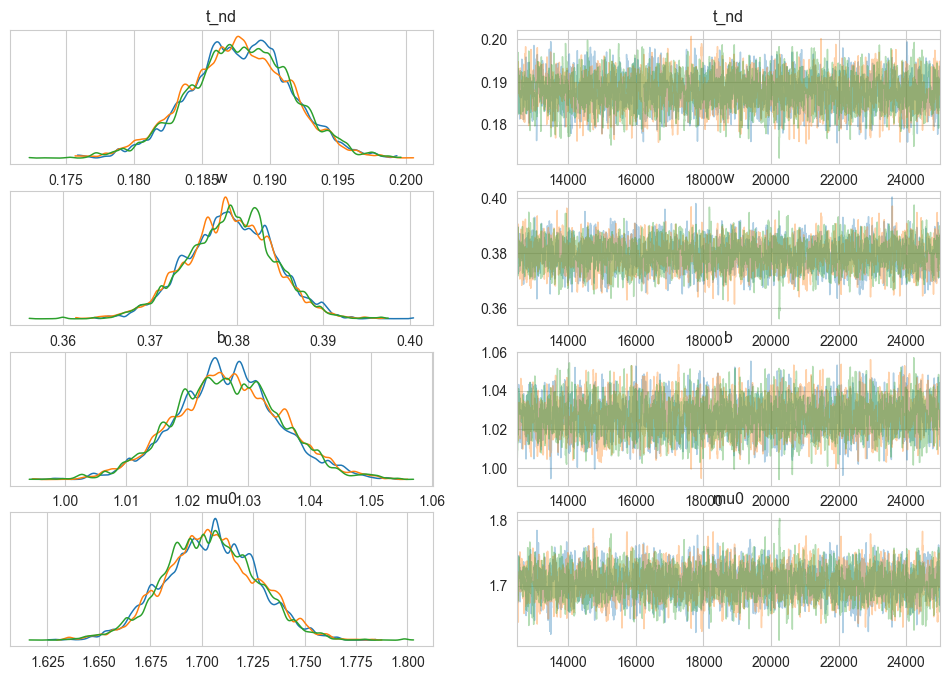

In [130]:
pbp.plot_idata(file_name='simpleDDM', burnin = 12500)

In [131]:
df_simpleddm = pbp.summary(file_name = 'simpleDDM', burnin = 12500)
df_simpleddm

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t_nd,0.188,0.004,0.181,0.195,0.0,0.0,2292.0,3416.0,1.0
w,0.379,0.005,0.370,0.389,0.0,0.0,2278.0,3693.0,1.0
b,1.027,0.009,1.010,1.042,0.0,0.0,2392.0,3558.0,1.0
mu0,1.704,0.022,1.663,1.746,0.0,0.0,2301.0,3635.0,1.0


In [132]:
variables = ["b", "mu0", "t_nd", "w"]
means_dict = {var: idata.posterior[var].mean(dim=["chain", "draw"]).item() for var in variables}

# Rename 't_nd' to 'tnd'
means_dict['tnd'] = means_dict.pop('t_nd')
print(means_dict)

{'b': 1.0245798269887423, 'mu0': 1.6853020182922842, 'w': 0.383975382211367, 'tnd': 0.18967581069403425}


In [133]:
# Create 5 new phi_n dictionaries from means_dict. b, tnd, w are the same for all phi_n dictionaries. mu0, mu1, mu2, mu3, mu4 are different for each phi_n dictionary. name nem phi_ugm, phi_2_0, phi_1_0, phi_0_5, phi_0_1.
phi_ugm_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu0'],
}

In [134]:
ll_fitted_simpleddm_original_ugm = pbp.loglikelihood(simpleDDM, phi_ugm_simpleddm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})
ll_fitted_simpleddm_rnn_ugm = pbp.loglikelihood(simpleDDM, phi_ugm_simpleddm, rt={'rt_upper': rts_rnn_ugm_upper, 'rt_lower': -1 * rts_rnn_ugm_lower})
ll_fitted_simpleddm_sindy_ugm = pbp.loglikelihood(simpleDDM, phi_ugm_simpleddm, rt={'rt_upper': rts_sindy_ugm_upper, 'rt_lower': -1 * rts_sindy_ugm_lower})
print(f'v = 4.0 \n LL - Original: {ll_fitted_simpleddm_original_ugm} \n LL - RNN: {ll_fitted_simpleddm_rnn_ugm} \n LL - SINDy: {ll_fitted_simpleddm_sindy_ugm}')

v = 4.0 
 LL - Original: -10137.570165458481 
 LL - RNN: -20436.903403411947 
 LL - SINDy: -7639.479589620006


### Fit FullDDM to Original Data

In [135]:
fullDDM = pbp.fullDDM()

In [136]:
p = {
    'p_tnd': 'Uniform("tnd", lower = 0.0, upper = 1.0)',
    'p_sd_tnd': 'Uniform("sd_tnd", lower = 0.001, upper = 0.25)',
    'p_w': 'Uniform("w", lower = 0.25, upper = 0.75)',
    'p_sd_w': 'Uniform("sd_w", lower = 0.01, upper = 0.99)',
    'p_mu0': 'Uniform("mu0", lower = -5.0, upper = 5.0)',
    'p_sd_mu0': 'Uniform("sd_mu0", lower = 0.001, upper = 5.0)',
    'p_b': 'Uniform("b", lower = 0.1, upper = 2.5)'
}

c0 = {
    'rt': {'rt_upper': rts_original_ugm_upper, 'rt_lower': rts_original_ugm_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu0',
    'sd_mu': 'p_sd_mu0',
    'b': 'p_b'
}

c = {0: c0}

idata_fullddm = pbp.inference(
    model=fullDDM,
    priors=p,
    conditions=c,
    samples=25000,
    chains=3,
    cores=3,
    file_name='DDM'
)

Multiprocess sampling (3 chains in 3 jobs)
DEMetropolisZ: [tnd, sd_tnd, w, sd_w, mu0, sd_mu0, b]


Output()

/Users/imtezcan/Repositories/CogSci/spice-ssm/.venv/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1020: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/Repositories/CogSci/spice-ssm/.venv/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1020: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/Repositories/CogSci/spice-ssm/ddm/pybeam_simulate/pybeam/precoded/loglike_class.py:85: RuntimeWarning: invalid value encountered in log
  logl = self.likelihood(phi, psi, self.w_dist, self.tnd_dist, self.N_tnd, self.mu_dist, self.N_mu, self.N_deps, self.dt_scale, self.dt_interp_scale, self.dt_interp_overide, self.rtu, self.rtl, self.rt_max)


Sampling 3 chains for 0 tune and 25_000 draw iterations (0 + 75_000 draws total) took 555 seconds.


array([[<Axes: title={'center': 'tnd'}>, <Axes: title={'center': 'tnd'}>],
       [<Axes: title={'center': 'sd_tnd'}>,
        <Axes: title={'center': 'sd_tnd'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>],
       [<Axes: title={'center': 'sd_w'}>,
        <Axes: title={'center': 'sd_w'}>],
       [<Axes: title={'center': 'mu0'}>, <Axes: title={'center': 'mu0'}>],
       [<Axes: title={'center': 'sd_mu0'}>,
        <Axes: title={'center': 'sd_mu0'}>],
       [<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>]],
      dtype=object)

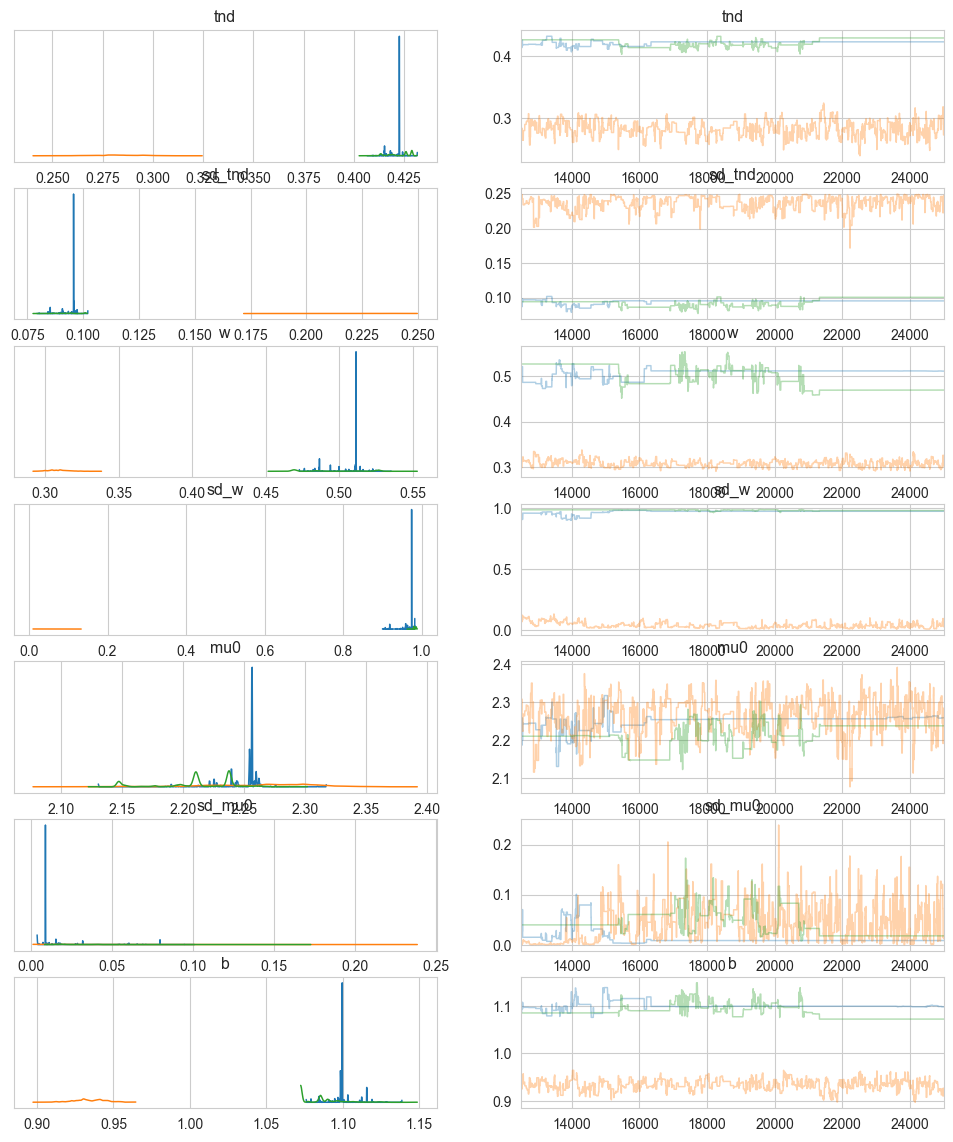

In [137]:
pbp.plot_idata(file_name='DDM', burnin = 12500)

In [138]:
df_fullddm = pbp.summary(file_name = 'DDM', burnin = 12500)
df_fullddm

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tnd,0.376,0.066,0.271,0.429,0.038,0.014,4.0,62.0,1.81
sd_tnd,0.142,0.067,0.087,0.248,0.039,0.014,4.0,27.0,2.13
w,0.437,0.092,0.301,0.527,0.053,0.018,4.0,13.0,1.93
sd_w,0.665,0.441,0.021,0.989,0.254,0.090,4.0,22.0,2.40
mu0,2.242,0.041,2.148,2.310,0.013,0.007,8.0,49.0,1.29
sd_mu0,0.033,0.030,0.001,0.091,0.009,0.003,12.0,32.0,1.23
b,1.040,0.076,0.919,1.116,0.044,0.015,4.0,56.0,1.98


In [139]:
# Convert to means_dict like before but for fullDDM
variables = ["b", "mu0", "sd_mu0", "tnd", "sd_tnd", "w", "sd_w"]
means_dict_fullddm = {var: idata_fullddm.posterior[var].mean(dim=["chain", "draw"]).item() for var in variables}

In [140]:
# Create 5 new phi_n dictionaries from means_dict_fullddm. b, tnd, w are the same for all phi_n dictionaries. mu0, mu1, mu2, mu3, mu4 and their sd_ variants are different for each phi_n dictionary. name them phi_ugm_fullddm, phi_2_0_fullddm, phi_1_0_fullddm, phi_0_5_fullddm, phi_0_1_fullddm.
phi_ugm_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu0'],
    "sd_mu": means_dict_fullddm['sd_mu0'],
}

In [141]:
ll_fitted_fullddm_original_ugm = pbp.loglikelihood(fullDDM, phi_ugm_fullddm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})
ll_fitted_fullddm_rnn_ugm = pbp.loglikelihood(fullDDM, phi_ugm_fullddm, rt={'rt_upper': rts_rnn_ugm_upper, 'rt_lower': -1 * rts_rnn_ugm_lower})
ll_fitted_fullddm_sindy_ugm = pbp.loglikelihood(fullDDM, phi_ugm_fullddm, rt={'rt_upper': rts_sindy_ugm_upper, 'rt_lower': -1 * rts_sindy_ugm_lower})
print(f'v = 4.0 \n LL - Original: {ll_fitted_fullddm_original_ugm} \n LL - RNN: {ll_fitted_fullddm_rnn_ugm} \n LL - SINDy: {ll_fitted_fullddm_sindy_ugm}')

v = 4.0 
 LL - Original: -10022.359618929804 
 LL - RNN: -20578.476490230154 
 LL - SINDy: -7338.778489048485


### Simulate new data from fitted models

In [142]:
rt_dict_simpleddm_ugm = pbp.simulate(N_sims=rts_original_ugm.size, model=simpleDDM, phi=phi_ugm_simpleddm)
rts_simpleddm_ugm_upper = rt_dict_simpleddm_ugm['rt_upper']
rts_simpleddm_ugm_lower = rt_dict_simpleddm_ugm['rt_lower']
rts_simple_ddm_ugm = np.concatenate([rts_simpleddm_ugm_upper, -1 * rts_simpleddm_ugm_lower])


In [143]:
rt_dict_fullddm_ugm = pbp.simulate(N_sims=rts_original_ugm.size, model=fullDDM, phi=phi_ugm_fullddm)
rts_fullddm_ugm_upper = rt_dict_fullddm_ugm['rt_upper']
rts_fullddm_ugm_lower = rt_dict_fullddm_ugm['rt_lower']
rts_fullddm_ugm = np.concatenate([rts_fullddm_ugm_upper, -1 * rts_fullddm_ugm_lower])


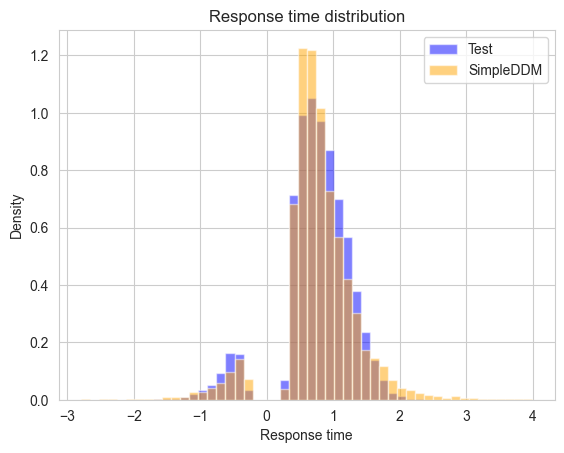

In [144]:
rt_dict = {
    'rts': [rts_original_ugm, rts_simple_ddm_ugm],#, rts_fullddm_ugm],
    'labels': ['Test', 'SimpleDDM'],#, 'FullDDM'],
    'colors': ['blue', 'orange']#, 'green']
}

fig, ax = plt.subplots()
plot_rts_multi(ax, rt_dict)

plt.show()
plt.close()

### Fit Kernel Density Estimation to each RT set and compare log-likelihoods against each other

For each drift rate, we fit KDEs to each RT set and then compare how well all RTs score against all KDEs.

First, we do cross-validation to find the best bandwidth and kernel for the KDEs.

In [145]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

params = {'bandwidth': np.logspace(-3, 1, 30), 'kernel': ['gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear']}
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_ugm)
bandwidth_ugm = grid.best_params_['bandwidth']
kernel_ugm = grid.best_params_['kernel']
print(f'v = 4.0 - Best bandwidth: {bandwidth_ugm} Best kernel: {kernel_ugm}')

v = 4.0 - Best bandwidth: 0.03290344562312668 Best kernel: gaussian


/Users/imtezcan/Repositories/CogSci/spice-ssm/.venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


In [148]:
import seaborn as sns

def get_lls_multi(rt_dict, bandwidth='scott', spacing=1000, bins=50, kernel='gaussian'):
    n_sets = len(rt_dict['rts'])
    kdes = []

    # Fit KDEs for each RT set
    for rts in rt_dict['rts']:
        kde = KernelDensity(bandwidth=bandwidth, kernel=kernel).fit(rts.reshape(-1, 1))
        kdes.append(kde)

    # Calculate log-likelihoods matrix
    ll_matrix = np.zeros((n_sets, n_sets))
    for i in range(n_sets):
        for j in range(n_sets):
            # Score RT set i against KDE j
            ll_matrix[i, j] = kdes[j].score(rt_dict['rts'][i].reshape(-1, 1))# / rt_dict['rts'][i].shape[0]

    # Plotting
    # KDE visualization
    plt.figure(figsize=(10, 6))

    # Find global min and max for x_grid
    min_val = min(rt.min() for rt in rt_dict['rts'])
    max_val = max(rt.max() for rt in rt_dict['rts'])
    x_grid = np.linspace(min_val, max_val, spacing)

    # Plot histograms and KDEs
    for i, (rts, label) in enumerate(zip(rt_dict['rts'], rt_dict['labels'])):
        plt.hist(rts, bins=bins, density=True, alpha=0.5, label=f'{label} (hist)')
        pdf = np.exp(kdes[i].score_samples(x_grid.reshape(-1, 1)))
        plt.plot(x_grid, pdf, '-', label=f'{label} (KDE)')

    plt.legend()
    plt.xlabel('Response Time')
    plt.ylabel('Density')
    plt.title('KDE of Response Time Distributions')
    plt.show()

    # Log-likelihood heatmap
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(ll_matrix, annot=True, fmt=".2f", cmap="Blues",
                     cbar_kws={'label': 'Log-Likelihood'})
    ax.set_xticklabels(rt_dict['labels'])
    ax.set_yticklabels(rt_dict['labels'], rotation=0)
    plt.xlabel('Response Times')
    plt.ylabel('Kernel Density Estimators')
    plt.title('Log-Likelihood Heatmap')
    plt.show()

    return ll_matrix

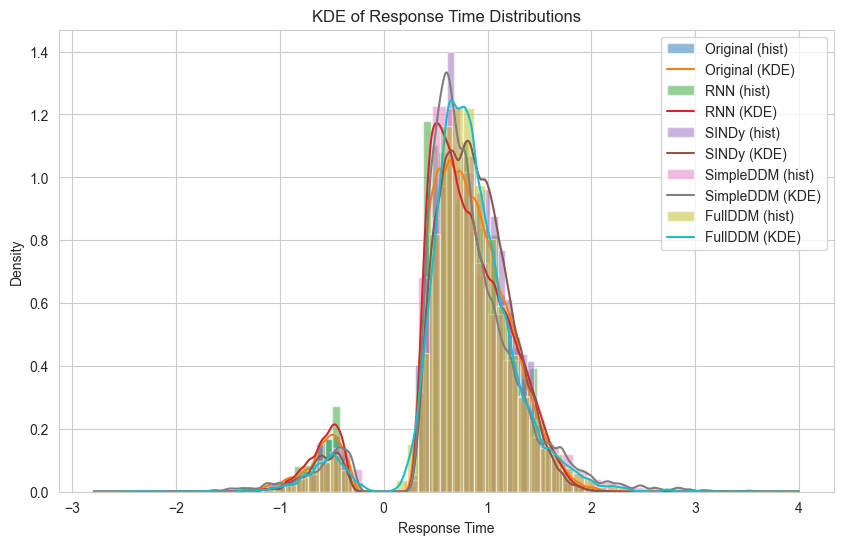

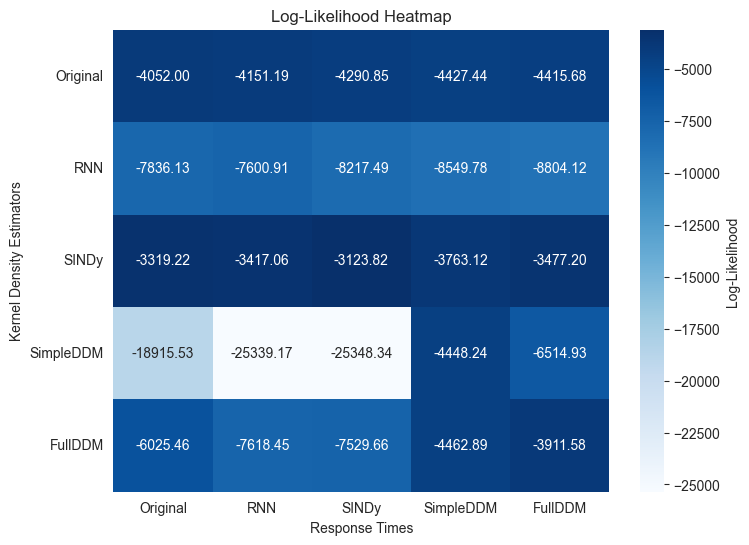

In [149]:
ll_matrix_ugm = get_lls_multi({"rts": [rts_original_ugm, rts_rnn_ugm, rts_sindy_ugm,
                rts_simple_ddm_ugm, rts_fullddm_ugm],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_ugm,
              kernel=kernel_ugm)

## Model Comparison

For each drift rate, we fit a single KDE and score each model's performance against it. We do this for 10 times for each model. We then compare the log-likelihoods of each model in a box plot.

### v = 4.0

In [282]:
n_trials = 10
n_sims = rts_original_ugm.size

all_rts_original_ugm = []
all_rts_rnn_ugm = []
all_rts_sindy_ugm = []
all_rts_simple_ddm_ugm = []
all_rts_fullddm_ugm = []

lls_original_ugm = []
lls_rnn_ugm = []
lls_sindy_ugm = []
lls_simple_ddm_ugm = []
lls_fullddm_ugm = []

kde_test = KernelDensity(bandwidth=bandwidth_ugm, kernel=kernel_ugm).fit(rts_original_ugm)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_ugm['simulation_params']['path_pybeam_model']}", phi_ugm, get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_ugm.append(rts_original)
    lls_original_ugm.append(kde_test.score(rts_original))

    rts_rnn, traces, dt, decision_indices = rnn_regressor_ugm.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_ugm.append(rts_rnn)
    lls_rnn_ugm.append(kde_test.score(rts_rnn))

    # v_init = traces['drift'][0][0]
    # D_init = v_init = traces['diffusion'][0][0]
    # rts_sindy = sindy_predict(sindy_regressor_ugm.sindy, initial_v=v_init, initial_D=D_init, b=rnn_regressor_ugm.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    # rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    # all_rts_sindy_ugm.append(rts_sindy)
    # lls_sindy_ugm.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_ugm.size, model=simpleDDM, phi=phi_ugm_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_ugm.append(rts_simpleddm)
    lls_simple_ddm_ugm.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_ugm.size, model=fullDDM, phi=phi_ugm_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_ugm.append(rts_fullddm)
    lls_fullddm_ugm.append(kde_test.score(rts_fullddm))

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


In [283]:
lls_original_ugm = np.array(lls_original_ugm)
print(f'PyBeam LL Mean: {lls_original_ugm.mean()}, std: {lls_original_ugm.std()}')
lls_rnn_ugm = np.array(lls_rnn_ugm)
print(f'RNN LL Mean: {lls_rnn_ugm.mean()}, std: {lls_rnn_ugm.std()}')
# lls_sindy_ugm = np.array(lls_sindy_ugm)
# print(f'SINDy LL Mean: {lls_sindy_ugm.mean()}, std: {lls_sindy_ugm.std()}')
lls_simple_ddm_ugm = np.array(lls_simple_ddm_ugm)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_ugm.mean()}, std: {lls_simple_ddm_ugm.std()}')
lls_fullddm_ugm = np.array(lls_fullddm_ugm)
print(f'FullDDM LL Mean: {lls_fullddm_ugm.mean()}, std: {lls_fullddm_ugm.std()}')

PyBeam LL Mean: -4123.101321163503, std: 60.45306588947325
RNN LL Mean: -3810.956981038294, std: 48.99561071743042
SimpleDDM LL Mean: -19647.18184754221, std: 2210.6724575292087
FullDDM LL Mean: -8563.704958152453, std: 2255.9588360937837


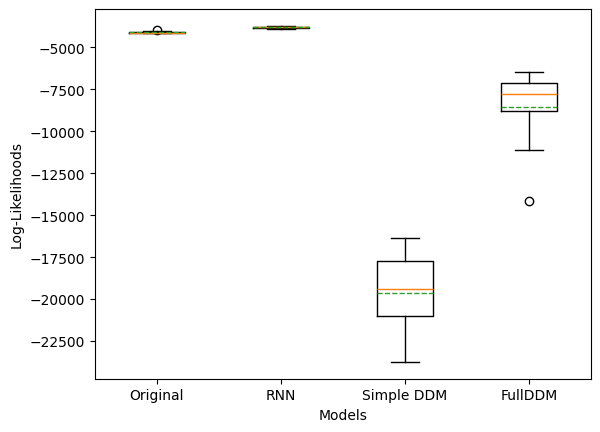

In [284]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_ugm, lls_rnn_ugm, lls_simple_ddm_ugm, lls_fullddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'Simple DDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

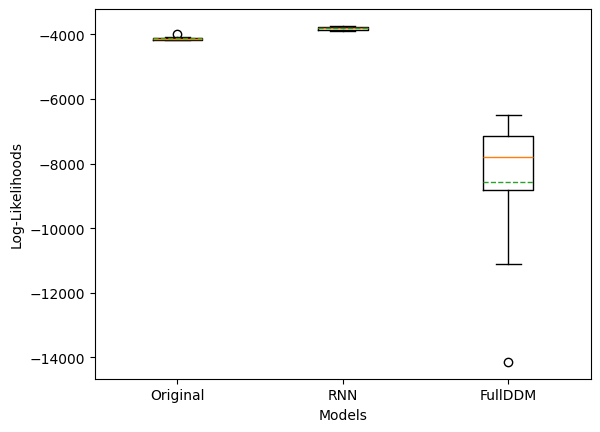

In [285]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_ugm, lls_rnn_ugm, lls_fullddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

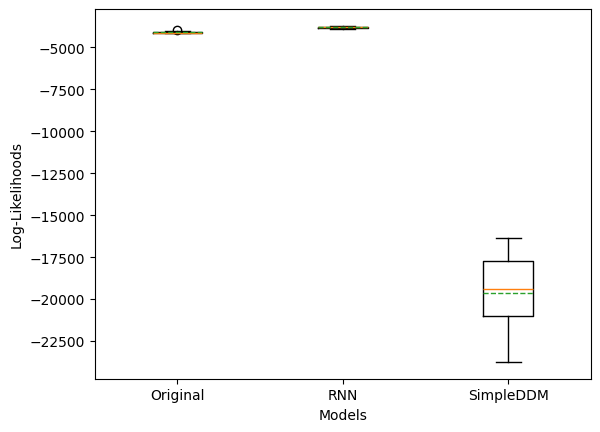

In [286]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_ugm, lls_rnn_ugm, lls_simple_ddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

In [287]:
lls_original_ugm_norm = lls_original_ugm.mean() / n_sims
lls_rnn_ugm_norm = lls_rnn_ugm.mean() / n_sims
lls_simple_ddm_ugm_norm = lls_simple_ddm_ugm.mean() / n_sims
lls_fullddm_ugm_norm = lls_fullddm_ugm.mean() / n_sims

In [288]:
print('Normalized LLs')
print(f'Original: {lls_original_ugm_norm}')
print(f'RNN: {lls_rnn_ugm_norm}')
print(f'SimpleDDM: {lls_simple_ddm_ugm_norm}')
print(f'FullDDM: {lls_fullddm_ugm_norm}')

Normalized LLs
Original: -0.5033082667435916
RNN: -0.46520470959940113
SimpleDDM: -2.398337627873805
FullDDM: -1.0453741403994694


In [289]:
p_original_ugm = lls_original_ugm / n_sims
p_rnn_ugm = lls_rnn_ugm / n_sims
p_sindy_ugm = lls_sindy_ugm / n_sims
p_simple_ddm_ugm = lls_simple_ddm_ugm / n_sims
p_fullddm_ugm = lls_fullddm_ugm / n_sims

TypeError: unsupported operand type(s) for /: 'list' and 'int'

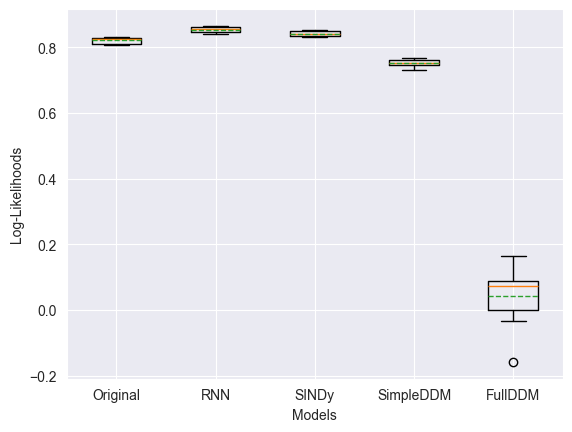

In [ ]:
fig, ax = plt.subplots()
ax.boxplot([p_original_ugm, p_rnn_ugm, p_sindy_ugm, p_simple_ddm_ugm, p_fullddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

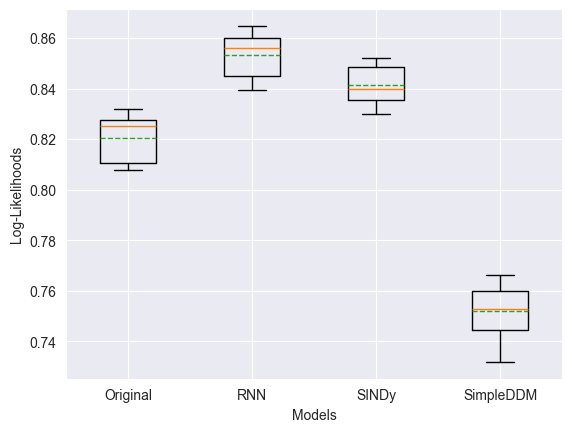

In [ ]:
fig, ax = plt.subplots()
ax.boxplot([p_original_ugm, p_rnn_ugm, p_sindy_ugm, p_simple_ddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

In [ ]:
print(f'LL Original mean: {p_original_ugm.mean()}, std: {p_original_ugm.std()}')
print(f'LL RNN mean: {p_rnn_ugm.mean()}, std: {p_rnn_ugm.std()}')
print(f'LL SINDy mean: {p_sindy_ugm.mean()}, std: {p_sindy_ugm.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_ugm.mean()}, std: {p_simple_ddm_ugm.std()}')
print(f'LL FullDDM mean: {p_fullddm_ugm.mean()}, std: {p_fullddm_ugm.std()}')

LL Original mean: 0.8204165188197929, std: 0.009144934563174051
LL RNN mean: 0.8534344248938135, std: 0.008578458403674768
LL SINDy mean: 0.8413998605339097, std: 0.00738833474549473
LL SimpleDDM mean: 0.7518476332037837, std: 0.010321781030189252
LL FullDDM mean: 0.042208305797623066, std: 0.08547724453108868
